In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customer_features = pd.read_csv(
    'data/processed/customer_features.csv'
)

clean_transactions = pd.read_csv(
    'data/processed/clean_transactions.csv'
)

In [2]:
customer_features['number_of_categories'] = customer_features['number_of_categories'].astype('category')
customer_features['customer_state'] = customer_features['customer_state'].astype('category')
customer_features['preferred_category'] = customer_features['preferred_category'].astype('category')

clean_transactions['product_category_name'] = clean_transactions['product_category_name'].astype('category')
clean_transactions['customer_state'] = clean_transactions['customer_state'].astype('category')

In [3]:
print(customer_features['total_spend'].describe())
print()
print(customer_features['total_spend'].skew())

count    95420.000000
mean       166.040172
std        228.320333
min          9.590000
25%         63.100000
50%        107.940000
75%        183.220000
max      13664.080000
Name: total_spend, dtype: float64

9.088563769442322


In [4]:
customer_features['log_total_spend'] = np.log1p(
    customer_features['total_spend']
)

customer_features['log_total_spend'].skew()
# now skewness is reduced so we can use log_total_spend

np.float64(0.5339497982352409)

In [5]:
print(customer_features['total_orders'].describe())
print()
print(customer_features['total_orders'].skew())
print()
print(customer_features['total_orders'].quantile(0.96))
# We don't need to apply log transformation here because approximately
# 96% of customers have only one order, so the high skewness is mainly
# due to the distribution being concentrated at one order.

count    95420.000000
mean         1.034018
std          0.211234
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: total_orders, dtype: float64

11.441609316263808

1.0


In [6]:
print(customer_features['average_order_value'].describe())
print()
print(customer_features['average_order_value'].skew())
print()
print(customer_features['average_order_value'].quantile(0.90))

customer_features['log_average_order_value'] = np.log1p(customer_features['average_order_value'])
customer_features['log_average_order_value'].skew()

count    95420.000000
mean       161.044770
std        221.191784
min          9.590000
25%         62.410000
50%        105.770000
75%        177.122500
max      13664.080000
Name: average_order_value, dtype: float64

9.279623872650811

307.9


np.float64(0.5520328816887671)

In [7]:
print(customer_features['average_item_price'].describe())
print()
print(customer_features['average_item_price'].skew())
print()
print(customer_features['average_item_price'].quantile(0.90))

customer_features['log_average_item_price'] = np.log1p(customer_features['average_item_price'])
customer_features['log_average_item_price'].skew()

count    95420.000000
mean       126.516509
std        191.743686
min          0.850000
25%         42.900000
50%         79.080000
75%        139.900000
max       6735.000000
Name: average_item_price, dtype: float64

7.725896538821046

239.99


np.float64(0.3246053726577385)

In [8]:
print(customer_features['customer_lifetime_days'].describe())
print()
print(customer_features['customer_lifetime_days'].skew())
print()
print(customer_features['customer_lifetime_days'].quantile(0.97))

# approximately 97 percentage of people doin one time purchase so theres no need of transformation here

count    95420.000000
mean         2.672280
std         25.211681
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        633.000000
Name: customer_lifetime_days, dtype: float64

12.261228235789737

0.0


In [9]:
# for late order rate it lies between 0-1 so no need of transformation here

In [10]:
# Bivariate analysis
customer_features[['total_orders','total_items','total_spend','average_order_value','average_item_price','total_freight']].corr(numeric_only = True)

,total_orders,total_items,total_spend,average_order_value,average_item_price,total_freight
total_orders,1.000000,0.439004,0.122122,-0.010338,-0.017505,0.210490
total_items,0.439004,1.000000,0.228613,0.159562,-0.058086,0.484063
total_spend,0.122122,0.228613,1.000000,0.982366,0.903866,0.505327
average_order_value,-0.010338,0.159562,0.982366,1.000000,0.922149,0.471051
average_item_price,-0.017505,-0.058086,0.903866,0.922149,1.000000,0.287060
total_freight,0.210490,0.484063,0.505327,0.471051,0.287060,1.000000


In [11]:
customer_features[['total_freight','customer_lifetime_days','average_delivery_days']].corr(numeric_only = True)

,total_freight,customer_lifetime_days,average_delivery_days
total_freight,1.000000,0.124483,0.161654
customer_lifetime_days,0.124483,1.000000,-0.010050
average_delivery_days,0.161654,-0.010050,1.000000


In [12]:
customer_features.groupby('customer_state')['total_orders'].describe()

,count,mean,std,min,25%,50%,75%,max
customer_state,,,,,,,,
AC,77.0,1.051948,0.223377,1.0,1.0,1.0,1.0,2.0
AL,399.0,1.030075,0.171009,1.0,1.0,1.0,1.0,2.0
AM,142.0,1.035211,0.277066,1.0,1.0,1.0,1.0,4.0
AP,67.0,1.014925,0.122169,1.0,1.0,1.0,1.0,2.0
BA,3256.0,1.031327,0.195812,1.0,1.0,1.0,1.0,5.0
CE,1304.0,1.016871,0.134663,1.0,1.0,1.0,1.0,3.0
DF,2060.0,1.031068,0.181745,1.0,1.0,1.0,1.0,3.0
ES,1955.0,1.035294,0.233531,1.0,1.0,1.0,1.0,6.0
GO,1941.0,1.035549,0.206277,1.0,1.0,1.0,1.0,4.0


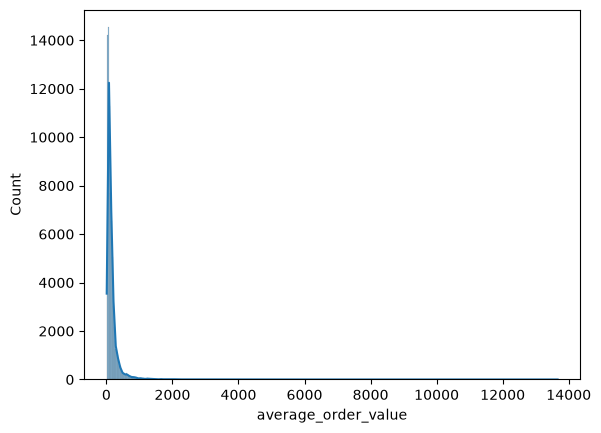

In [13]:
sns.histplot(data=customer_features, x='average_order_value', kde=True)
plt.show()

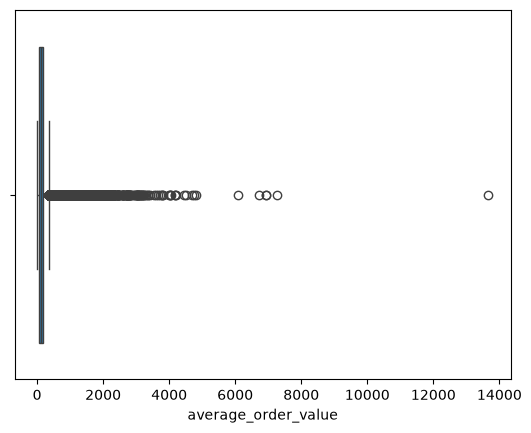

In [14]:
sns.boxplot(data=customer_features, x='average_order_value')
plt.show()

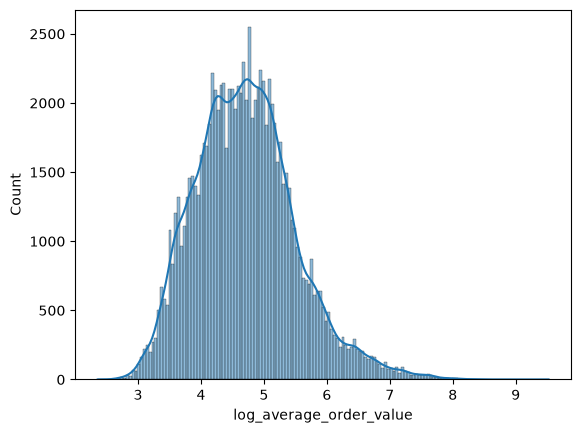

In [15]:
sns.histplot(data=customer_features, x='log_average_order_value', kde=True)
plt.show()
# after transformation very less right skewed

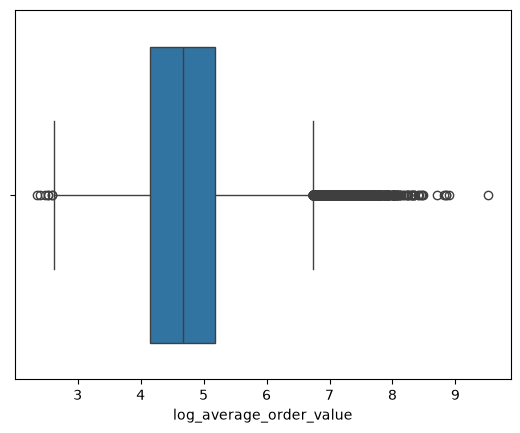

In [16]:
sns.boxplot(data=customer_features, x='log_average_order_value')
plt.show()

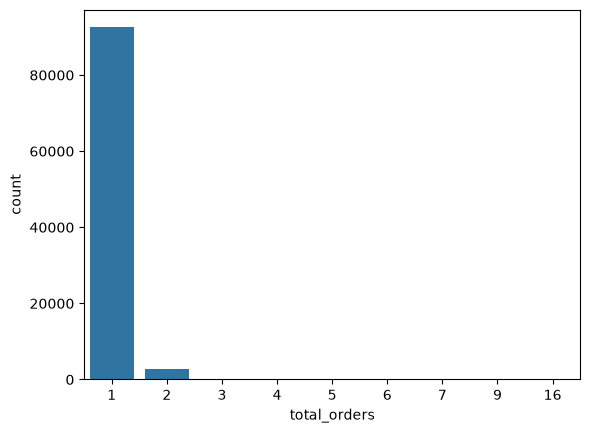

In [17]:
sns.countplot(data=customer_features, x='total_orders')
plt.show()

In [18]:
clean_transactions.groupby('customer_state')['delivery_days'].describe()

,count,mean,std,min,25%,50%,75%,max
customer_state,,,,,,,,
AC,91.0,20.329670,10.340917,7.0,14.0,18.0,23.0,72.0
AL,427.0,23.992974,11.535308,4.0,16.0,22.0,30.0,90.0
AM,163.0,25.963190,13.430153,4.0,20.0,26.0,32.5,138.0
AP,81.0,27.753086,26.677955,5.0,18.0,24.0,30.0,187.0
BA,3683.0,18.774640,11.492587,0.0,12.0,16.0,23.0,167.0
CE,1426.0,20.537167,12.867981,2.0,13.0,18.0,24.0,168.0
DF,2355.0,12.501486,7.365352,1.0,8.0,11.0,16.0,68.0
ES,2225.0,15.192809,10.366145,2.0,9.0,13.0,18.0,209.0
GO,2277.0,14.948177,9.615131,1.0,10.0,13.0,18.0,181.0


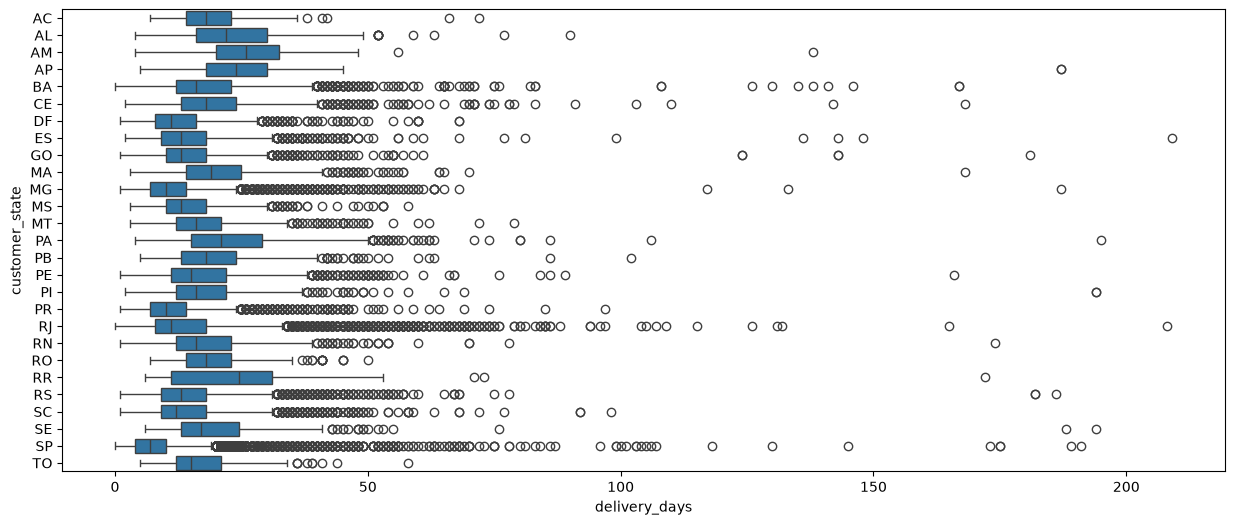

In [19]:
plt.figure(figsize=(15,6))
sns.boxplot(data = clean_transactions,y = 'customer_state',x = 'delivery_days')
plt.show()

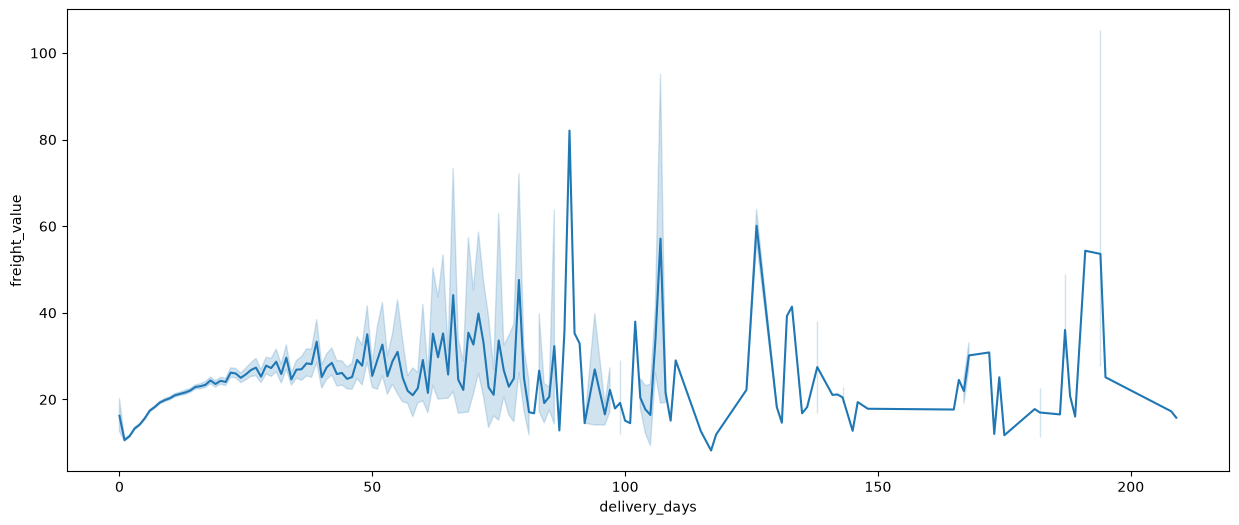

In [20]:
plt.figure(figsize=(15,6))
sns.lineplot(data = clean_transactions,y = 'freight_value',x = 'delivery_days')
plt.show()

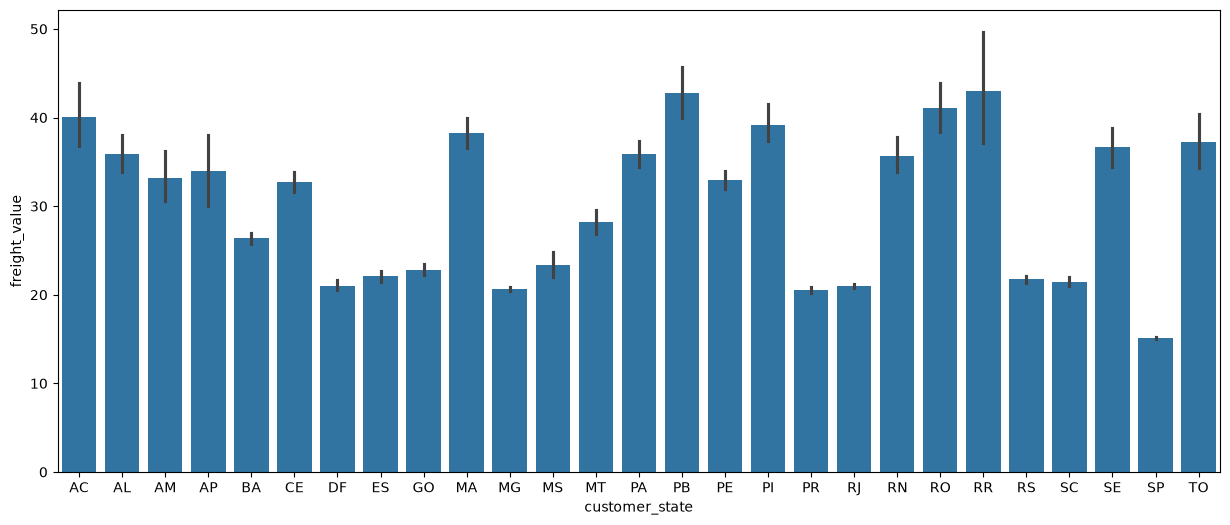

In [21]:
plt.figure(figsize=(15,6))
sns.barplot(data = clean_transactions,y = 'freight_value',x = 'customer_state')
plt.show()

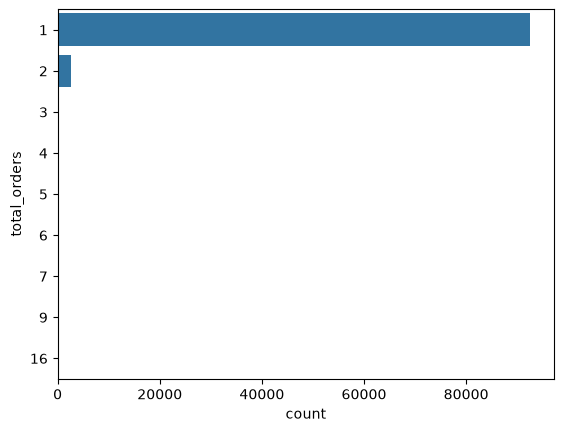

In [22]:

sns.countplot(
    data=customer_features,
    y="total_orders",
)
plt.show()

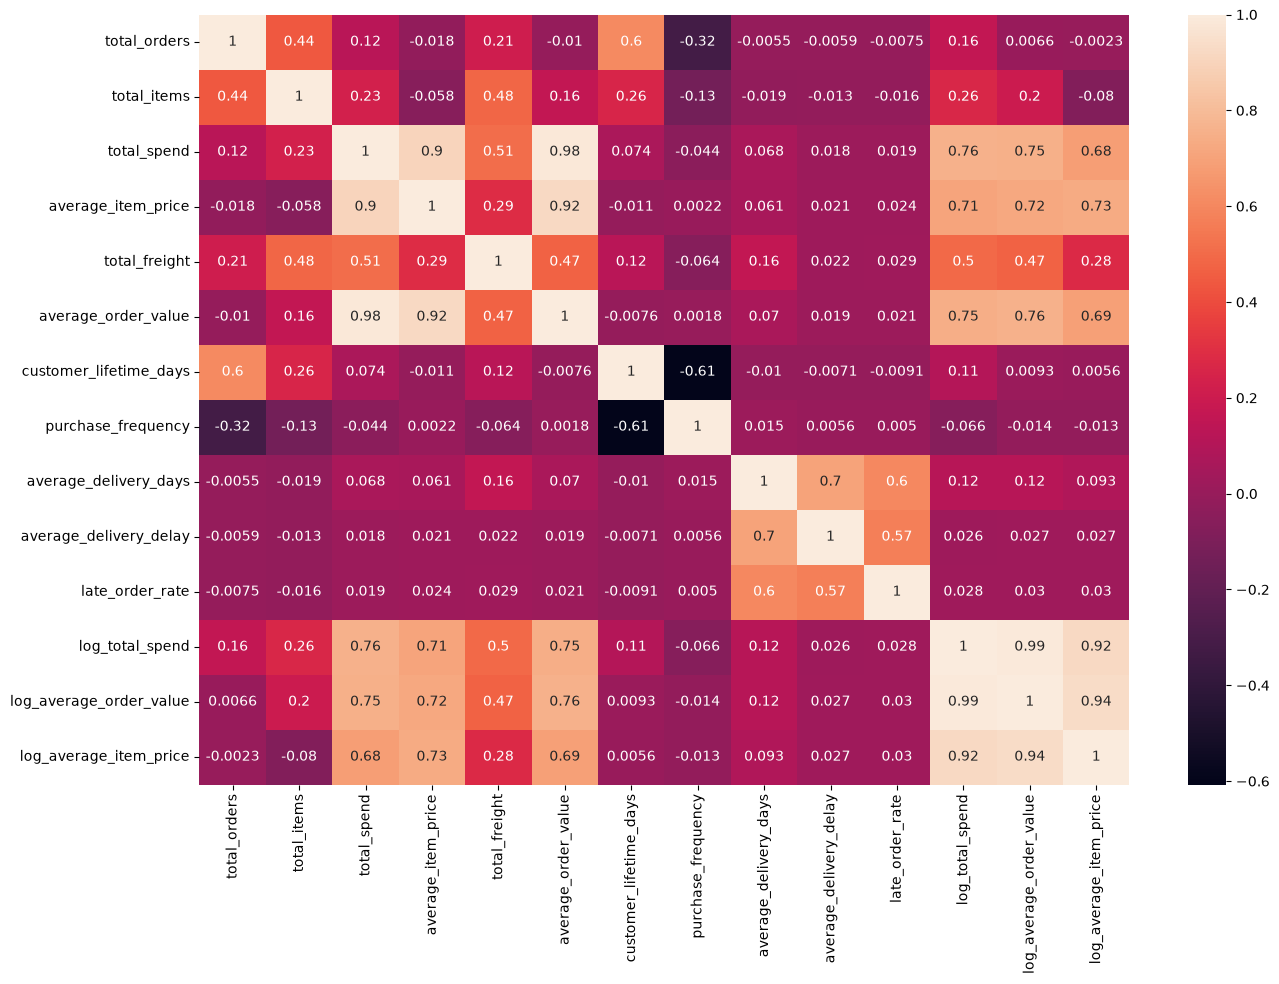

In [23]:
corr = customer_features.corr(numeric_only = True)
plt.figure(figsize=(15,10))
sns.heatmap(
    corr,
    annot = True
)
plt.show()

<Axes: >

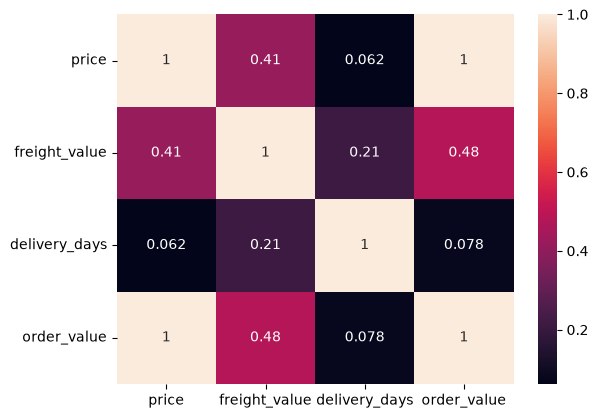

In [24]:
corr = clean_transactions.corr(numeric_only = True)

sns.heatmap(
    corr,
    annot = True
)

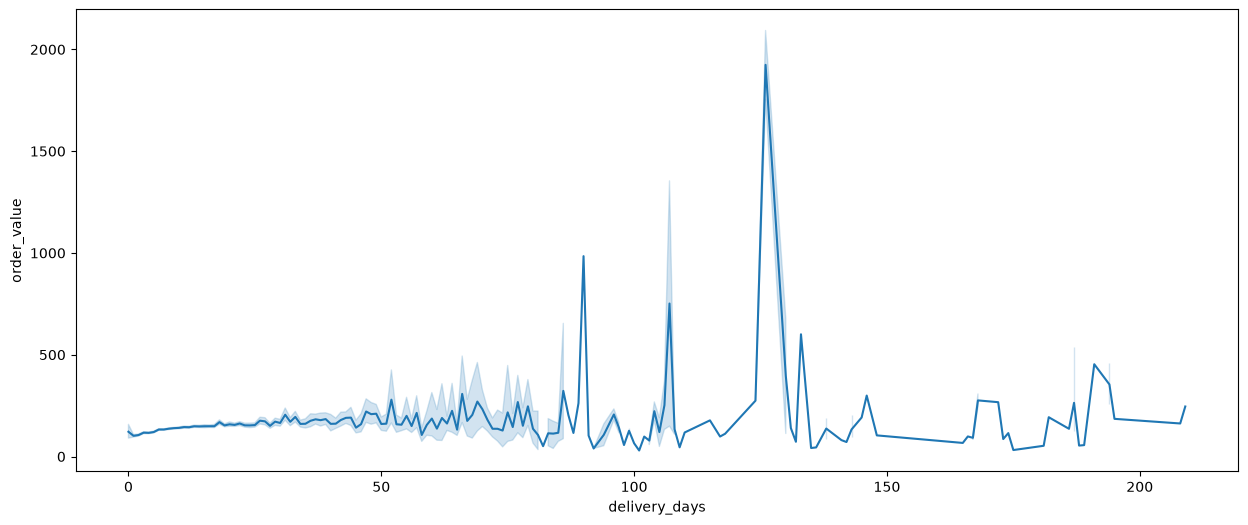

In [25]:
plt.figure(figsize=(15,6))
sns.lineplot(data = clean_transactions,y = 'order_value',x = 'delivery_days')
plt.show()

In [26]:
print(customer_features['total_orders'].describe())
print(customer_features['total_orders'].quantile(0.98))

count    95420.000000
mean         1.034018
std          0.211234
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: total_orders, dtype: float64
2.0


In [27]:
print(customer_features['total_spend'].describe())
print()
print(customer_features['total_spend'].quantile(0.95))
print(customer_features['total_spend'].quantile(0.96))
print(customer_features['total_spend'].quantile(0.97))
print(customer_features['total_spend'].quantile(0.98))
print(customer_features['total_spend'].quantile(0.99))

count    95420.000000
mean       166.040172
std        228.320333
min          9.590000
25%         63.100000
50%        107.940000
75%        183.220000
max      13664.080000
Name: total_spend, dtype: float64

473.82050000000004
549.78
643.8942999999999
795.5567999999993
1113.5701999999944


In [28]:
print(customer_features['preferred_category'].value_counts().head(5))
print()
print(customer_features.groupby('preferred_category')['average_item_price'].sum().nlargest(5))

preferred_category
bed_bath_table           9046
health_beauty            8547
sports_leisure           7300
computers_accessories    6506
furniture_decor          6079
Name: count, dtype: int64

preferred_category
health_beauty            1.164148e+06
watches_gifts            1.126811e+06
bed_bath_table           8.707019e+05
sports_leisure           8.679449e+05
computers_accessories    7.607324e+05
Name: average_item_price, dtype: float64


In [29]:
print(customer_features.groupby('customer_state')['total_orders'].sum().nlargest(5))

customer_state
SP    41380
RJ    12757
MG    11545
RS     5434
PR     5002
Name: total_orders, dtype: int64


In [30]:
print(customer_features['average_delivery_days'].describe())
print()
print(customer_features['average_delivery_days'].quantile(0.92))
print(customer_features['average_delivery_days'].quantile(0.94))
print(customer_features['average_delivery_days'].quantile(0.96))
print(customer_features['average_delivery_days'].quantile(0.98))
print(customer_features['average_delivery_days'].quantile(0.99))

count    93356.000000
mean        12.101917
std          9.552425
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: average_delivery_days, dtype: float64

25.0
27.0
31.0
38.0
45.0


In [31]:
print(customer_features['average_delivery_delay'].describe())
print()
print(customer_features['average_delivery_delay'].quantile(0.93))
print(customer_features['average_delivery_delay'].quantile(0.94))
print(customer_features['average_delivery_delay'].quantile(0.96))
print(customer_features['average_delivery_delay'].quantile(0.98))
print(customer_features['average_delivery_delay'].quantile(0.99))

count    93356.000000
mean         0.724283
std          4.676576
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        188.000000
Name: average_delivery_delay, dtype: float64

0.0
2.0
5.0
11.0
18.0


In [32]:
print(customer_features['late_order_rate'].describe())
print()
print(customer_features['late_order_rate'].quantile(0.93))
print(customer_features['late_order_rate'].quantile(0.94))
print(customer_features['late_order_rate'].quantile(0.96))
print(customer_features['late_order_rate'].quantile(0.98))
print(customer_features['late_order_rate'].quantile(0.99))

count    93356.000000
mean         0.068070
std          0.250486
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: late_order_rate, dtype: float64

0.0
1.0
1.0
1.0
1.0


In [33]:
print(customer_features.groupby('total_orders')['total_spend'].sum().nlargest(16))

total_orders
1     14939106.99
2       784037.99
3        83023.29
4        22406.51
5         6607.63
6         3455.56
7         2840.56
9         1172.67
16         902.04
Name: total_spend, dtype: float64


# Business Insights

## 1. Customer Retention / Repeat Purchase Behavior

- The customer base is strongly dominated by one-time purchasers.
- Approximately 96% of customers have only one order, indicating a relatively low repeat-purchase rate.
- The 98th percentile of total orders is only 2, while the maximum number of orders made by a customer is 16.
- This indicates that repeat customers represent a relatively small segment of the customer base.
- Improving customer retention and encouraging repeat purchases could provide a significant opportunity for increasing customer lifetime value.

## 2. Customer Spending Behavior

- Total customer spending is strongly right-skewed.
- The median customer spending is approximately 107.94, while the mean is approximately 166.04.
- The maximum customer spending is approximately 13,664.08, showing the presence of a small number of high-value customers.
- The 99th percentile is approximately 1,113.57, which is considerably lower than the maximum.
- This indicates that a small group of customers contributes disproportionately high spending.
- These high-value customers could be targeted through loyalty programs and personalized offers.

## 3. Preferred Product Categories

- The most common preferred category is `bed_bath_table`, with approximately 9,046 customers.
- Other highly preferred categories include `health_beauty`, `sports_leisure`, `computers_accessories`, and `furniture_decor`.
- `health_beauty` has the highest aggregated average-item-price value among the preferred categories analyzed.
- These high-demand categories can be prioritized for inventory planning, promotions, and targeted marketing campaigns.

## 4. State-wise Customer Behavior

- Customer activity varies across Brazilian states, indicating differences in regional customer concentration and purchasing behavior.
- States with a larger customer base represent important markets for targeted marketing and customer-retention strategies.
- Regional purchasing patterns can also be used to improve inventory allocation and logistics planning.

## 5. Delivery Performance

- The average delivery time is approximately 12.1 days.
- The median delivery time is 10 days, while 75% of customers have an average delivery time of 15 days or less.
- However, the maximum average delivery time reaches 209 days, indicating the presence of extreme delivery cases.
- Average delivery delay has a median of 0 days, meaning at least 75% of customers experienced no average delivery delay.
- The mean average delivery delay is approximately 0.72 days.
- The maximum observed average delivery delay is 188 days, showing that a small number of customers experienced extremely long delays.
- These extreme cases should be investigated separately rather than automatically removed because they may represent genuine delivery problems.

## 6. Late Order Rate

- The median late-order rate is 0, and at least 75% of customers have a late-order rate of 0.
- The mean late-order rate is approximately 6.8%.
- This indicates that late deliveries are relatively uncommon for most customers but still affect a smaller segment of customers.
- Undelivered orders were retained with missing delivery-related metrics because their delivery performance cannot be determined.

## 7. Relationship Between Orders and Spending

- Customers with more orders generally contribute higher total spending.
- Customers with one order collectively contribute the largest total spending because they represent the majority of the customer base.
- However, customers with multiple orders show substantially higher spending per customer and represent an important high-value segment.
- Repeat-purchase customers should therefore be considered an important target for customer-retention strategies.

## 8. Outliers and Data Transformation

- Several continuous numerical features showed strong right-skewness and extreme upper-tail values.
- Legitimate high-value customers and orders were retained rather than removed simply because they were large.
- Log transformations were applied to highly skewed continuous features where appropriate.
- Count-based features such as `total_orders` were not transformed merely because they were highly skewed, since their distribution reflects genuine customer purchasing behavior.

# Key Recommendations

1. Develop customer-retention campaigns to convert one-time buyers into repeat customers.
2. Identify and prioritize high-value customers for loyalty programs and personalized promotions.
3. Focus marketing and inventory planning on high-demand product categories.
4. Investigate extreme delivery delays to identify potential logistics problems.
5. Use regional customer behavior to optimize marketing and logistics strategies.
6. Use customer-level behavioral features for future customer segmentation and predictive modeling.